In [7]:
import os
import shutil
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [8]:
TRAIN_DIR = r"C:\Users\elmar_e6gaevu\OneDrive\Desktop\data\seg_train"
TEST_DIR = r"C:\Users\elmar_e6gaevu\OneDrive\Desktop\data\seg_test"
PRED_DIR = r"C:\Users\elmar_e6gaevu\OneDrive\Desktop\data\seg_pred\seg_pred"

if os.path.exists(os.path.join(TRAIN_DIR, "seg_train")):
    TRAIN_DIR = os.path.join(TRAIN_DIR, "seg_train")
if os.path.exists(os.path.join(TEST_DIR, "seg_test")):
    TEST_DIR = os.path.join(TEST_DIR, "seg_test")

print(f"Train folder: {TRAIN_DIR}")
print(f"Test folder: {TEST_DIR}")
print(f"Prediction folder: {PRED_DIR}")

Train folder: C:\Users\elmar_e6gaevu\OneDrive\Desktop\data\seg_train\seg_train
Test folder: C:\Users\elmar_e6gaevu\OneDrive\Desktop\data\seg_test\seg_test
Prediction folder: C:\Users\elmar_e6gaevu\OneDrive\Desktop\data\seg_pred\seg_pred


In [9]:
unlabeled_subfolder = os.path.join(PRED_DIR, "unlabeled")
if os.path.exists(PRED_DIR) and not os.path.exists(unlabeled_subfolder):
    os.makedirs(unlabeled_subfolder, exist_ok=True)
    images = [f for f in os.listdir(PRED_DIR) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    for img in images:
        shutil.move(os.path.join(PRED_DIR, img), os.path.join(unlabeled_subfolder, img))
    print(f"Moved {len(images)} unlabeled images into '{unlabeled_subfolder}'")
else:
    print("Prediction directory is ready.")

Moved 7301 unlabeled images into 'C:\Users\elmar_e6gaevu\OneDrive\Desktop\data\seg_pred\seg_pred\unlabeled'


In [10]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transforms = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Load train and test datasets
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=test_transforms)
pred_dataset = datasets.ImageFolder(root=PRED_DIR, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
pred_loader = DataLoader(pred_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
print("\nDetected Classes:", train_dataset.class_to_idx)


Detected Classes: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


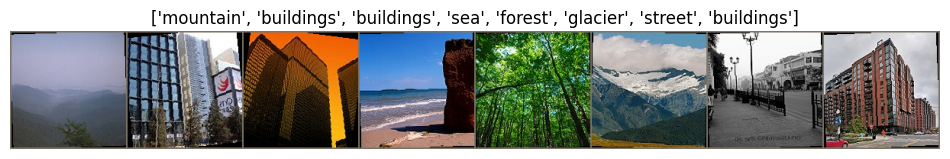

In [11]:
def imshow(inp, title=None):
    """Denormalize tensor and plot grid of images."""
    inp = inp.numpy().transpose((1, 2, 0))
    inp = np.array(std) * inp + np.array(mean)
    inp = np.clip(inp, 0, 1)
    plt.figure(figsize=(12, 6))
    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

data_iter = iter(train_loader)
images, labels = next(data_iter)
out = utils.make_grid(images[:8])
imshow(out, title=[class_names[x] for x in labels[:8]])

In [12]:
class LandscapeCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(LandscapeCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # Output: 32 x 75 x 75
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # Output: 64 x 37 x 37
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # Output: 128 x 18 x 18
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 18 * 18, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = LandscapeCNN(num_classes=len(class_names)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [13]:
epochs = 10
best_val_loss = float("inf")
MODEL_SAVE_PATH = "best_landscape_model.pth"

print("\nStarting Training...")
for epoch in range(epochs):

    model.train()
    running_loss, running_corrects = 0.0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    train_loss = running_loss / len(train_dataset)
    train_acc = running_corrects.double() / len(train_dataset)

    model.eval()
    val_loss, val_corrects = 0.0, 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    val_loss = val_loss / len(test_dataset)
    val_acc = val_corrects.double() / len(test_dataset)

    print(f"Epoch {epoch+1:02d}/{epochs:02d} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"Saved new best model checkpoint (Val Loss: {val_loss:.4f})")


Starting Training...
Epoch 01/10 | Train Loss: 1.5408 Acc: 0.4849 | Val Loss: 0.9697 Acc: 0.6297
Saved new best model checkpoint (Val Loss: 0.9697)
Epoch 02/10 | Train Loss: 1.0661 Acc: 0.5760 | Val Loss: 1.1073 Acc: 0.5957
Epoch 03/10 | Train Loss: 0.9627 Acc: 0.6234 | Val Loss: 0.6959 Acc: 0.7413
Saved new best model checkpoint (Val Loss: 0.6959)
Epoch 04/10 | Train Loss: 0.8877 Acc: 0.6534 | Val Loss: 0.6596 Acc: 0.7867
Saved new best model checkpoint (Val Loss: 0.6596)
Epoch 05/10 | Train Loss: 0.8575 Acc: 0.6641 | Val Loss: 0.7048 Acc: 0.7593
Epoch 06/10 | Train Loss: 0.8173 Acc: 0.6898 | Val Loss: 0.5859 Acc: 0.7953
Saved new best model checkpoint (Val Loss: 0.5859)
Epoch 07/10 | Train Loss: 0.7769 Acc: 0.7014 | Val Loss: 0.5741 Acc: 0.8073
Saved new best model checkpoint (Val Loss: 0.5741)
Epoch 08/10 | Train Loss: 0.7417 Acc: 0.7122 | Val Loss: 0.6807 Acc: 0.7513
Epoch 09/10 | Train Loss: 0.7270 Acc: 0.7233 | Val Loss: 0.5068 Acc: 0.8287
Saved new best model checkpoint (Val Lo

In [14]:
print("\nLoading model with lowest validation loss")
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval()

test_loss, test_corrects = 0.0, 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)

        test_loss += loss.item() * inputs.size(0)
        test_corrects += torch.sum(preds == labels.data)

final_loss = test_loss / len(test_dataset)
final_acc = (test_corrects.double() / len(test_dataset)) * 100

print(f"Final Test Loss: {final_loss:.4f}")
print(f"Final Test Accuracy: {final_acc:.2f}%")


Loading model with lowest validation loss
Final Test Loss: 0.5052
Final Test Accuracy: 82.63%
